# EDA for Assignment 2

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from plots import plot_origin_stand, plot_trip
from haversine import haversine_vector, Unit

In [2]:
# Constants
CENTER_LAT, CENTER_LON = 41.15794, -8.62911                # Porto City Hall
SAMPLING_INTERVAL_S = 15                                    # one GPS point every 15 seconds
MAX_SPEED_KMH = 200                                         # faster than this between two points = GPS jump
MAX_STEP_M = MAX_SPEED_KMH / 3.6 * SAMPLING_INTERVAL_S      # longest realistic step, about 833 m
SAMPLE_SIZE = 100_000                                       # trips used in the point-level GPS analysis
SPEED_THRESHOLD = 50                                        # average speed threshold used to narrow the search for trips with GPS faults

### Helper functions
Used in the sections below.

In [3]:
#Coordinated in POLYLINE are stored as [longitude, latitude], while haversine_vector expects (latitude, longitude), so the order is swapped inside the functions.

def first_two_points(polylines):
    #Extracts the first and second GPS point directly from the POLYLINE text.
    #Missing points become NaN
    points = polylines.str.extract(
        r"^\[\[([-\d.]+),([-\d.]+)\](?:,\[([-\d.]+),([-\d.]+)\])?"
    ).astype(float)
    points.columns = ["LON1", "LAT1", "LON2", "LAT2"]
    return points


def last_point(polylines):
    #Extracts the last GPS point directly from the POLYLINE text.
    points = polylines.str.extract(r"\[([-\d.]+),([-\d.]+)\]\]$").astype(float)
    points.columns = ["LON", "LAT"]
    return points


def distance_to_center_km(lat, lon):
    #Distance in km from each (lat, lon) to Porto City Hall.
    points = np.column_stack([lat, lon])
    center = np.repeat([[CENTER_LAT, CENTER_LON]], len(points), axis=0)
    return haversine_vector(points, center, Unit.KILOMETERS)


def trip_distance_km(polyline):
    #Total distance of one trip: the sum of the steps between consecutive points
    points = np.array(json.loads(polyline))
    if len(points) < 2:
        return 0.0
    points = points[:, [1, 0]]    # (lon, lat) -> (lat, lon)
    return haversine_vector(points[:-1], points[1:], Unit.KILOMETERS).sum()


def polylines_to_points(trips):
    #Turns trips into one row per GPS point, with TRIP_ID, LONGITUDE and LATITUDE
    pts = trips[["TRIP_ID", "POLYLINE"]].copy()
    pts["POLYLINE"] = pts["POLYLINE"].apply(json.loads)       # text -> list
    pts = pts.explode("POLYLINE", ignore_index=True)          # one row per point
    pts["LONGITUDE"] = pts["POLYLINE"].str[0].astype(float)
    pts["LATITUDE"] = pts["POLYLINE"].str[1].astype(float)
    return pts.drop(columns="POLYLINE")


def calculate_steps(pts, max_speed_kmh=MAX_SPEED_KMH):
    #Adds step length (m), speed (km/h) and a jump flag for each point.
    #The step is the distance from the previous point in the same trip.
    previous = pts.groupby("TRIP_ID")[["LATITUDE", "LONGITUDE"]].shift()
    pts["STEP_M"] = haversine_vector(previous.to_numpy(), pts[["LATITUDE", "LONGITUDE"]].to_numpy(), Unit.METERS)
    pts["SPEED_KMH"] = pts["STEP_M"] / SAMPLING_INTERVAL_S * 3.6
    pts["JUMP"] = pts["SPEED_KMH"] > max_speed_kmh
    return pts


def select_valid_trips(df):
    #Trips with at least one point and a unique TRIP_ID
    return df[(df["N_POINTS"] > 0) & ~df["TRIP_ID"].duplicated(keep=False)].copy()


def prepare_points(df, sample_size, random_state=42):
    # Sample valid trips and expand them to points with step distance/speed
    sample = select_valid_trips(df).sample(sample_size, random_state=random_state)
    pts = polylines_to_points(sample)
    return calculate_steps(pts)

def speed_exceedances(pts, limits=(120, 160, 200, 500)):
    # Number of points and trips above each speed limit
    rows = []
    for limit in limits:
        over = pts["SPEED_KMH"] > limit
        rows.append({
            "LIMIT_KMH": limit,
            "N_POINTS": over.sum(),
            "N_TRIPS": pts.loc[over, "TRIP_ID"].nunique(),
        })
    return pd.DataFrame(rows).set_index("LIMIT_KMH")


def jump_trips(pts):
    # One row per trip that has jumps, worst first
    return (
        pts[pts["JUMP"]]
        .groupby("TRIP_ID")
        .agg(N_JUMPS=("JUMP", "size"),
             MAX_SPEED_KMH=("SPEED_KMH", "max"),
             MAX_STEP_M=("STEP_M", "max"))
        .sort_values("MAX_SPEED_KMH", ascending=False)
    )


def classify_bad_points(pts, max_step_m):
    # Add ERROR_TYPE and UNEXPLAINED_JUMP columns. Returns a new DataFrame
    pts = pts.copy()
    g = pts.groupby("TRIP_ID")
    point_nr = g.cumcount()
    n_points = g["LONGITUDE"].transform("size")

    jump_in = pts["JUMP"]
    jump_out = g["JUMP"].shift(-1, fill_value=False)
    jump_after_next = g["JUMP"].shift(-2, fill_value=False)
    jump_before = g["JUMP"].shift(1, fill_value=False)

    previous = g[["LATITUDE", "LONGITUDE"]].shift(1)
    following = g[["LATITUDE", "LONGITUDE"]].shift(-1)
    previous_to_next_m = haversine_vector(previous.to_numpy(), following.to_numpy(), Unit.METERS)

    pts["ERROR_TYPE"] = np.select(
        [
            (point_nr == 0) & jump_out & ~jump_after_next,
            (point_nr == n_points - 1) & jump_in & ~jump_before,
            jump_in & jump_out & (previous_to_next_m <= 2 * max_step_m),
        ],
        ["first point", "last point", "spike"],
        default="",
    )

    # A jump is explained if this point, or the one before it, is a bad point
    is_bad = pts["ERROR_TYPE"] != ""
    previous_is_bad = g["ERROR_TYPE"].shift(1, fill_value="") != ""
    pts["UNEXPLAINED_JUMP"] = pts["JUMP"] & ~(is_bad | previous_is_bad)
    return pts


def trip_summary(pts):
    # One row per trip: size, distance, jumps, unexplained jumps
    trips = pts.groupby("TRIP_ID").agg(
        N_POINTS=("LONGITUDE", "size"),
        DISTANCE_KM=("STEP_M", "sum"),
        N_JUMPS=("JUMP", "sum"),
        N_UNEXPLAINED=("UNEXPLAINED_JUMP", "sum"),
    )
    trips["DISTANCE_KM"] /= 1000
    return trips


def report_speeds(pts, limits=(120, 160, 200, 500)):
    print("Trips:", pts["TRIP_ID"].nunique(), "| Points:", len(pts))
    print(pts["SPEED_KMH"].describe(percentiles=[0.5, 0.9, 0.99, 0.999]), "\n")
    for limit, row in speed_exceedances(pts, limits).iterrows():
        print(f"Jumps over {limit} km/h: {row.N_POINTS:,} points in {row.N_TRIPS:,} trips")


def report_bad_points(pts, trips):
    with_jumps = trips[trips["N_JUMPS"] > 0]
    n_with, n_all = len(with_jumps), len(trips)
    print(f"Trips with at least one jump: {n_with:,} of {n_all:,} ({n_with / n_all:.2%})\n")

    print("Jumps per trip (5 = five or more):")
    print(with_jumps["N_JUMPS"].clip(upper=5).value_counts().sort_index(), "\n")

    print("Bad points by type:")
    print(pts.loc[pts["ERROR_TYPE"] != "", "ERROR_TYPE"].value_counts(), "\n")

    explained = (with_jumps["N_UNEXPLAINED"] == 0).sum()
    print(f"Trips where all jumps are single bad points: {explained:,} ({explained / n_with:.1%})")
    print(f"Trips with at least one unexplained jump:    {n_with - explained:,} ({1 - explained / n_with:.1%})")

def report_unexplained_jumps(pts, km_thresholds=(1, 2, 3, 5, 10, 50)):
    unexplained = pts.loc[pts["UNEXPLAINED_JUMP"], "STEP_M"]
    print(unexplained.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]), "\n")
    for km in km_thresholds:
        print(f"Jumps of {km:>2} km or less: {(unexplained <= km * 1000).mean():.1%}")


def plot_jump_sizes(pts):
    km = pts.loc[pts["UNEXPLAINED_JUMP"], "STEP_M"] / 1000
    plt.figure(figsize=(8, 4))
    plt.hist(km, bins=np.logspace(np.log10(0.8), 4, 60), log=True)
    plt.xscale("log")
    plt.title("Size of unexplained GPS jumps")
    plt.xlabel("km (log scale)")
    plt.ylabel("Number of jumps")
    plt.show()

## 2. Load data

In [4]:
df = pd.read_csv("porto.csv")

## 3.Struktur
How large is the dataset, which columns are there and what datatypes do they have?

In [5]:
# nr of rows and columns
print(df.shape)
df.head()

(1710670, 9)


,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."
3,1372636854620000520,C,NaN,NaN,20000520,1372636854,A,False,"[[-8.574678,41.151951],[-8.574705,41.151942],[..."
4,1372637091620000337,C,NaN,NaN,20000337,1372637091,A,False,"[[-8.645994,41.18049],[-8.645949,41.180517],[-..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1710670 entries, 0 to 1710669
Data columns (total 9 columns):
 #   Column        Dtype  
---  ------        -----  
 0   TRIP_ID       int64  
 1   CALL_TYPE     object 
 2   ORIGIN_CALL   float64
 3   ORIGIN_STAND  float64
 4   TAXI_ID       int64  
 5   TIMESTAMP     int64  
 6   DAY_TYPE      object 
 7   MISSING_DATA  bool   
 8   POLYLINE      object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 106.0+ MB


## 4. Missing values

In [7]:
df.isna().sum()

TRIP_ID               0
CALL_TYPE             0
ORIGIN_CALL     1345900
ORIGIN_STAND     904091
TAXI_ID               0
TIMESTAMP             0
DAY_TYPE              0
MISSING_DATA          0
POLYLINE              0
dtype: int64

## 4. Categorical colums

CALL_TYPE
B    817881
C    528019
A    364770
Name: count, dtype: int64 

DAY_TYPE
A    1710670
Name: count, dtype: int64 

MISSING_DATA
False    1710660
True          10
Name: count, dtype: int64 



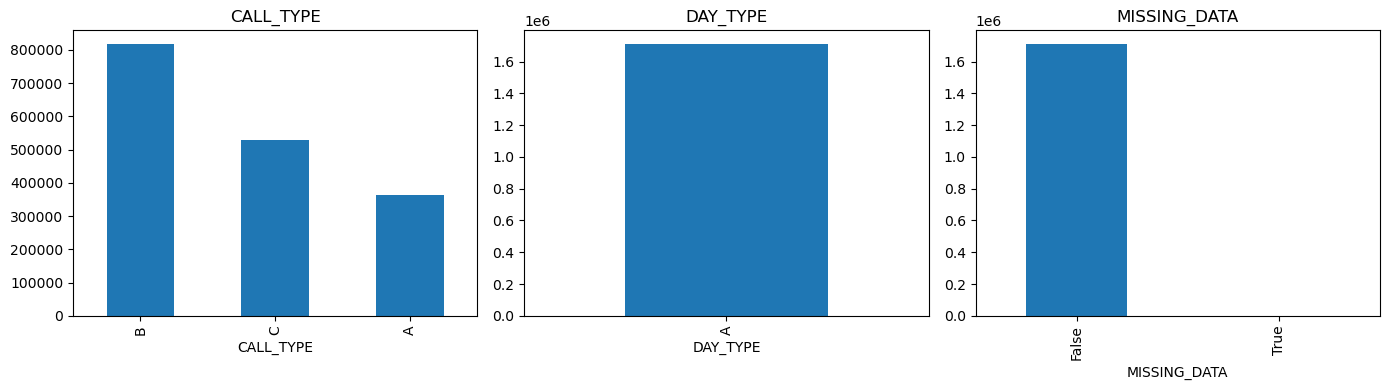

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(["CALL_TYPE", "DAY_TYPE", "MISSING_DATA"]):
    counts = df[col].value_counts()
    print(counts, "\n")
    counts.plot(kind="bar", ax=ax[i], title=col)
plt.tight_layout(); plt.show()

### Trips with MISSING_DATA = True

In [9]:
missing = df[df["MISSING_DATA"] == True]
print("Antall rader:", len(missing))
missing[["TRIP_ID", "TAXI_ID", "POLYLINE"]]


Antall rader: 10


,TRIP_ID,TAXI_ID,POLYLINE
105621,1374554455620000625,20000625,"[[-8.612559,41.145975],[-8.612577,41.145975],[..."
171397,1375863510620000454,20000454,"[[-0.205893,41.010282]]"
299137,1378544246620000057,20000057,"[[-8.569719,41.166135],[-8.567928,41.166477],[..."
457486,1381233613620000387,20000387,"[[-8.626347,41.153436],[-8.626275,41.152905],[..."
738466,1386346894620000904,20000904,"[[-8.652816,40.636575],[-8.652807,40.636566],[..."
782321,1387137779620000640,20000640,"[[-8.604558,41.161941],[-8.604477,41.162013],[..."
848552,1388351478620000678,20000678,"[[-8.609697,41.160276],[-8.609571,41.16033],[-..."
932391,1390005983620000640,20000640,"[[-8.604792,41.16123],[-8.604801,41.161167],[-..."
1275934,1396631707620000163,20000163,"[[-10.634022,43.834248]]"
1432196,1399405185620000508,20000508,"[[-8.620011,41.14683],[-8.619957,41.146659],[-..."


In [10]:
# plot the trips with the missing values
missing["POLYLINE"] = missing["POLYLINE"].apply(json.loads).copy()
plot_trip(missing[["TRIP_ID", "TAXI_ID", "POLYLINE"]].copy())

C:\Users\gabribj\AppData\Local\Temp\ipykernel_14928\2953122877.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing["POLYLINE"] = missing["POLYLINE"].apply(json.loads).copy()


## 6. Consistency: CALL_TYPE vs. ORIGIN_CALL and ORIGIN_STAND
How well does ORIGIN_CALL match with call type A, and ORIGIN_STAND with call type B. 

In [11]:
# Correlation between "call type" = A and occurences of "origin call"
number_of_A = (df["CALL_TYPE"]=="A").sum()
number_of_origincall = (df["ORIGIN_CALL"]).notna().sum()
deviation_A = abs(number_of_A - number_of_origincall)
print(f"Deviation in A: {deviation_A}")

# Correlation between "call type" = B and occurences of "origin stand"
number_of_B = (df["CALL_TYPE"]=="B").sum()
number_of_originstand = (df["ORIGIN_STAND"]).notna().sum()
deviation_B = abs(number_of_B - number_of_originstand)
print(f"Deviatior in B: {deviation_B}")

print(pd.crosstab(df["CALL_TYPE"], df["ORIGIN_CALL"].notna(), margins=True), "\n")
print(pd.crosstab(df["CALL_TYPE"], df["ORIGIN_STAND"].notna(), margins=True))

Deviation in A: 0
Deviatior in B: 11302
ORIGIN_CALL    False    True      All
CALL_TYPE                            
A                  0  364770   364770
B             817881       0   817881
C             528019       0   528019
All          1345900  364770  1710670 

ORIGIN_STAND   False    True      All
CALL_TYPE                            
A             364770       0   364770
B              11302  806579   817881
C             528019       0   528019
All           904091  806579  1710670


### Where do B trips without ORIGIN_STAND start?
The position of each taxi stand is estimated as the median start point of the trips from that stand (the median is less affected by outliers than the mean). B trips without a stand are plotted against these positions.

In [12]:
b_trips = df[df["CALL_TYPE"] == "B"][["TRIP_ID", "ORIGIN_STAND", "POLYLINE"]].copy()
start = first_two_points(b_trips["POLYLINE"])
b_trips["LONGITUDE"] = start["LON1"]
b_trips["LATITUDE"] = start["LAT1"]

with_stand = b_trips[b_trips["ORIGIN_STAND"].notna()]
without_stand = b_trips[b_trips["ORIGIN_STAND"].isna()]

stand_median = (
    with_stand.groupby("ORIGIN_STAND")
    .agg(LATITUDE=("LATITUDE", "median"), LONGITUDE=("LONGITUDE", "median"))
    .reset_index()
)

plot_origin_stand(stand_median, without_stand)

### How far from their stand do B trips start?
Trips that start more than 500 m from their median position of their stand.

In [13]:
check = with_stand.merge(stand_median, on="ORIGIN_STAND", suffixes=("", "_MEDIAN"))
check = check.dropna(subset=["LATITUDE", "LONGITUDE"])
check["DIST_FROM_STAND_KM"] = haversine_vector(
    check[["LATITUDE", "LONGITUDE"]].to_numpy(),
    check[["LATITUDE_MEDIAN", "LONGITUDE_MEDIAN"]].to_numpy(),
    Unit.KILOMETERS,
)

THRESHOLD_KM = 0.5
outliers = check[check["DIST_FROM_STAND_KM"] > THRESHOLD_KM]
print(f"B trips starting more than {THRESHOLD_KM} km from their stand: {len(outliers):,} ({len(outliers)/len(check):.1%})")

plot_origin_stand(stand_median, outliers)

B trips starting more than 0.5 km from their stand: 3,385 (0.4%)


## 7. Duplicates

In [14]:
# identical rows:
print(f"Number of duplicate rows: {df.duplicated().sum()}")

duplisertID = df["TRIP_ID"].duplicated().sum()
# duplicates of id
print(f"Number of duplicate TripIDs: {duplisertID}")

Number of duplicate rows: 3
Number of duplicate TripIDs: 81


In [15]:
# For duplicate TRIP_IDs, does the rows represent the same trip or different trips?
dup = df[df["TRIP_ID"].duplicated(keep=False)].sort_values("TRIP_ID")
print("Rows involved:", len(dup), "| Unique IDs:", dup["TRIP_ID"].nunique())

# Which columns are different grouped by TRIP_ID?
unique = dup.groupby("TRIP_ID").nunique()
print("Number of ID-groups where columns vary:")
print((unique > 1).sum())

Rows involved: 161 | Unique IDs: 80
Number of ID-groups where columns vary:
CALL_TYPE       23
ORIGIN_CALL      0
ORIGIN_STAND     0
TAXI_ID          0
TIMESTAMP        0
DAY_TYPE         0
MISSING_DATA     0
POLYLINE        77
dtype: int64


In [16]:
# How many rows are there per trip_id for trip_ids that are not unique? 
number_of_dup = dup.value_counts("TRIP_ID")
print("Number of rows per duplicate ID:")
display(number_of_dup.value_counts().sort_index())

# Is there a connection between length of polyline and index? 
two_dups = dup[dup["TRIP_ID"].isin(number_of_dup[number_of_dup == 2].index)].copy() # trip_ids with two rows 
two_dups["LEN"] = two_dups["POLYLINE"].apply(lambda p: len(json.loads(p))) # number of GPS-points per row
two_dups["NR"] = two_dups.groupby("TRIP_ID").cumcount() # add length of gps-point
wide = two_dups.pivot(index="TRIP_ID", columns="NR", values="LEN") # one row per TRIP_ID, with length of first and last GPS-point 

print("Nr of occurences where the first row has more GPS points than the last row:", (wide[1] > wide[0]).sum())
print("Nr of occurences where the last row has more GPS points than the first row:", (wide[1] < wide[0]).sum())
print("Nr of occurences with the same amount of GPS points:", (wide[1] == wide[0]).sum())

Number of rows per duplicate ID:


count
2    79
3     1
Name: count, dtype: int64

Nr of occurences where the first row has more GPS points than the last row: 51
Nr of occurences where the last row has more GPS points than the first row: 3
Nr of occurences with the same amount of GPS points: 25


## 8. Taxis

In [17]:
#Number of taxis and distribution of trips between them
trips_per_taxi = df["TAXI_ID"].value_counts()
print("Number of taxis:", df["TAXI_ID"].nunique())
print(trips_per_taxi.describe())

Number of taxis: 448
count      448.000000
mean      3818.459821
std       1644.021173
min          1.000000
25%       2694.000000
50%       3732.000000
75%       5023.250000
max      10746.000000
Name: count, dtype: float64


## 9. Time

First: 2013-07-01 01:00:53 | Last: 2014-07-01 00:59:56


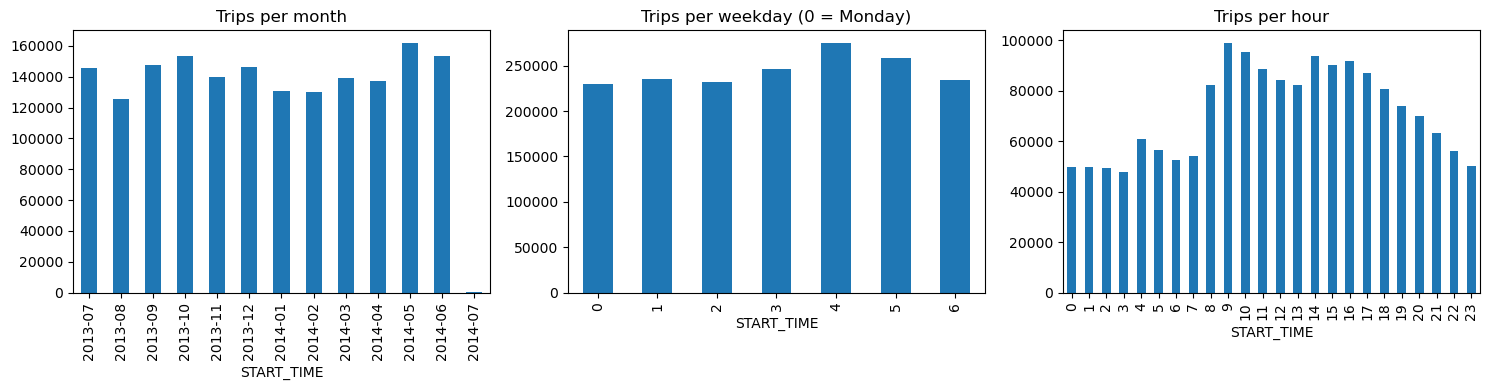

In [18]:
df["START_TIME"] = pd.to_datetime(df["TIMESTAMP"], unit="s", utc=True).dt.tz_convert("Europe/Lisbon").dt.tz_localize(None)
print("First:", df["START_TIME"].min(), "| Last:", df["START_TIME"].max())

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
df["START_TIME"].dt.to_period("M").value_counts().sort_index().plot(kind="bar", ax=ax[0], title="Trips per month")
df["START_TIME"].dt.dayofweek.value_counts().sort_index().plot(kind="bar", ax=ax[1], title="Trips per weekday (0 = Monday)")
df["START_TIME"].dt.hour.value_counts().sort_index().plot(kind="bar", ax=ax[2], title="Trips per hour")
plt.tight_layout(); plt.show()

## 10. Number of GPS points and duration

In [19]:
df["N_POINTS"] = df["POLYLINE"].str.count(r"\[") - 1
df["DURATION_MIN"] = (df["N_POINTS"] - 1).clip(lower=0) * SAMPLING_INTERVAL_S / 60

print(df["N_POINTS"].describe(), "\n")
print("Trips with 0 points:      ", (df["N_POINTS"] == 0).sum())
print("Trips with 1 point:      ", (df["N_POINTS"] == 1).sum())
print("Trips with < 3 points:    ", (df["N_POINTS"] < 3).sum())
print("Trips longer than 2 hours:", (df["DURATION_MIN"] > 120).sum())
print("Total number of GPS points:", df["N_POINTS"].sum())

count    1.710670e+06
mean     4.875831e+01
std      4.565372e+01
min      0.000000e+00
25%      2.800000e+01
50%      4.100000e+01
75%      5.900000e+01
max      3.881000e+03
Name: N_POINTS, dtype: float64 

Trips with 0 points:       5901
Trips with 1 point:       30609
Trips with < 3 points:     43904
Trips longer than 2 hours: 2257
Total number of GPS points: 83409386


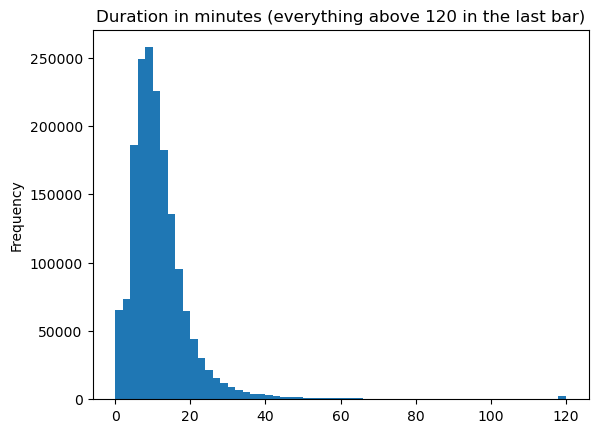

In [20]:
df["DURATION_MIN"].clip(upper=120).plot(kind="hist", bins=60, title="Duration in minutes (everything above 120 in the last bar)")
plt.show()

### Trips longer than 2 hours
Are the long trips real long-distance trips, or a taximeter that was not turned off?

       DURATION_MIN      DIST_KM  AVG_SPEED_KMH
count   2257.000000  2257.000000    2257.000000
mean     192.539433    86.548029      26.586512
std       94.489244   100.510641      27.667063
min      120.250000     0.442451       0.143497
25%      136.750000    20.248738       7.296231
50%      159.250000    42.752003      15.006394
75%      209.250000   122.576134      35.956017
max      970.000000   751.593259     212.474128 

Share with average speed below 10 km/h: 36.2%


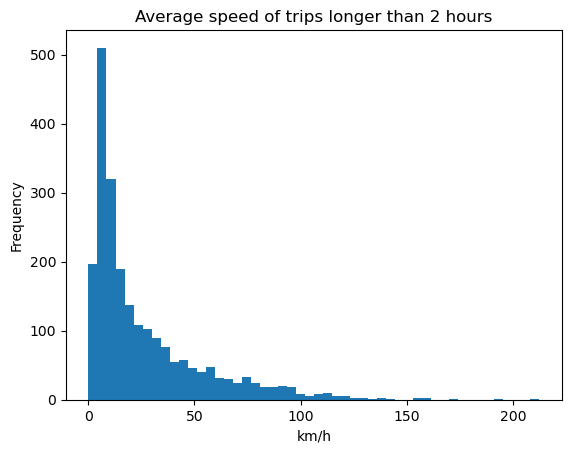

In [21]:
long_trips = df[df["DURATION_MIN"] > 120].copy()
long_trips["DIST_KM"] = long_trips["POLYLINE"].apply(trip_distance_km)
long_trips["AVG_SPEED_KMH"] = long_trips["DIST_KM"] / (long_trips["DURATION_MIN"] / 60)

print(long_trips[["DURATION_MIN", "DIST_KM", "AVG_SPEED_KMH"]].describe(), "\n")
print(f"Share with average speed below 10 km/h: {(long_trips['AVG_SPEED_KMH'] < 10).mean():.1%}")

long_trips["AVG_SPEED_KMH"].plot(kind="hist", bins=50, title="Average speed of trips longer than 2 hours")
plt.xlabel("km/h")
plt.show()

## 11. Start points far from Porto

count     1.704769e+06
mean      2.438805e+00
std       5.450145e+00
min       2.083392e-02
50%       2.116775e+00
90%       3.910262e+00
99%       6.218545e+00
99.9%     1.241553e+01
99.99%    8.140388e+01
max       5.473674e+03
Name: START_DIST_KM, dtype: float64 

Starts more than  10 km from the center:  3,293 trips (0.193%)
Starts more than  20 km from the center:  1,008 trips (0.059%)
Starts more than  30 km from the center:    641 trips (0.038%)
Starts more than  50 km from the center:    417 trips (0.024%)
Starts more than 100 km from the center:    127 trips (0.007%)


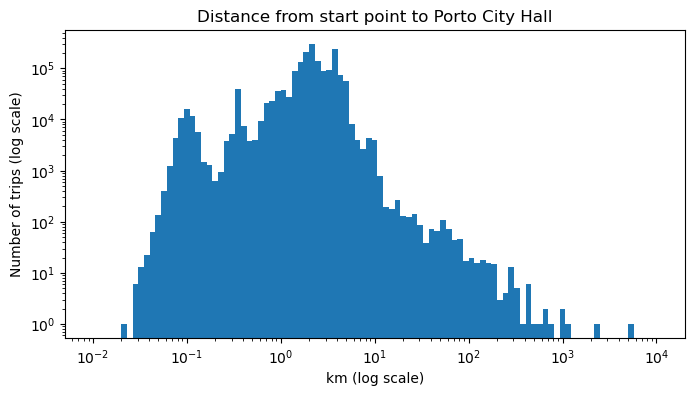

In [22]:
start = first_two_points(df["POLYLINE"])
df["START_DIST_KM"] = distance_to_center_km(start["LAT1"], start["LON1"])
df["SECOND_DIST_KM"] = distance_to_center_km(start["LAT2"], start["LON2"])

start_dist = df["START_DIST_KM"].dropna()
print(start_dist.describe(percentiles=[0.5, 0.9, 0.99, 0.999, 0.9999]), "\n")
for limit in [10, 20, 30, 50, 100]:
    n = (start_dist > limit).sum()
    print(f"Starts more than {limit:>3} km from the center: {n:6,} trips ({n/len(start_dist):.3%})")

plt.figure(figsize=(8, 4))
plt.hist(start_dist.clip(lower=0.01), bins=np.logspace(-2, 4, 100), log=True)
plt.xscale("log")
plt.title("Distance from start point to Porto City Hall")
plt.xlabel("km (log scale)")
plt.ylabel("Number of trips (log scale)")
plt.show()

In [23]:
#For trips that start more than the limit set below, is the whole trips far away or only the first point?
LIMIT_KM = 30
far = df[df["START_DIST_KM"] > LIMIT_KM].copy()
far["STATUS"] = np.where(
    far["SECOND_DIST_KM"].isna(), "only one point",
    np.where(far["SECOND_DIST_KM"] <= LIMIT_KM, "only first point wrong", "whole start far away"),
)

print(f"Trips starting more than {LIMIT_KM} km from the center: {len(far):,}\n")
print(pd.crosstab(far["CALL_TYPE"], far["STATUS"], margins=True))

Trips starting more than 30 km from the center: 641

STATUS     only first point wrong  only one point  whole start far away  All
CALL_TYPE                                                                   
A                               1               1                     2    4
B                               3               6                     0    9
C                               4              69                   555  628
All                             8              76                   557  641


In [24]:
#Are the trips where the whole start is far away return trips to Porto? Should end closer to Porto than they started.
whole = far[far["STATUS"] == "whole start far away"].copy()
end = last_point(whole["POLYLINE"])
whole["END_DIST_KM"] = distance_to_center_km(end["LAT"], end["LON"])

print(whole[["START_DIST_KM", "END_DIST_KM", "N_POINTS"]].describe(), "\n")
print(f"End closer to Porto than they started: {(whole['END_DIST_KM'] < whole['START_DIST_KM']).mean():.1%}")
print("Start more than 300 km away:", (whole["START_DIST_KM"] > 300).sum())

       START_DIST_KM  END_DIST_KM     N_POINTS
count     557.000000   557.000000   557.000000
mean       75.032646    52.707350   228.026930
std        54.290834    58.694407   263.862853
min        30.033188     0.075763     2.000000
25%        42.770119     6.668901    49.000000
50%        55.447017    46.663560   159.000000
75%        82.525746    66.661487   324.000000
max       452.533936   437.812586  2251.000000 

End closer to Porto than they started: 69.3%
Start more than 300 km away: 2


## 12. GPS errors
Sections 12 and 13 use a random sample of 100,000 trips, since splitting all polylines into points (about 83 million rows) needs too much memory. The sample is then used to occurrences in the whole dataset.

In [25]:
pts = prepare_points(df, SAMPLE_SIZE)

### Speed between two points

In [26]:
report_speeds(pts)

Trips: 100000 | Points: 4871956
count    4.771956e+06
mean     2.752351e+01
std      3.998366e+01
min      0.000000e+00
50%      2.103679e+01
90%      6.409133e+01
99%      1.179573e+02
99.9%    1.881015e+02
max      2.548945e+04
Name: SPEED_KMH, dtype: float64 

Jumps over 120 km/h: 42,596 points in 14,906 trips
Jumps over 160 km/h: 9,717 points in 8,453 trips
Jumps over 200 km/h: 2,696 points in 2,206 trips
Jumps over 500 km/h: 684 points in 500 trips


In [27]:
# Trips with jumps, worst first
jump_trips = jump_trips(pts)
print(f"Trips with jumps over {MAX_SPEED_KMH} km/h: {len(jump_trips):,}")
display(jump_trips.head(10))

Trips with jumps over 200 km/h: 2,206


,N_JUMPS,MAX_SPEED_KMH,MAX_STEP_M
TRIP_ID,,,
1385024475620000351,1,25489.448657,106206.036071
1383666543620000534,1,21812.631343,90885.963930
1374221412620000276,6,19477.929972,81158.041549
1397249260620000435,2,18487.122992,77029.679135
1397726842620000001,1,11314.171154,47142.379807
1399059610620000217,1,10381.553126,43256.471357
1397633651620000027,1,10264.840530,42770.168877
1383901719620000588,5,10189.184831,42454.936795
1383524675620000678,2,9697.515172,40406.313216


### Type of jumps
- First point is far away, but rest of trips is normal
- Last point is far away, but the rest of the trips is normal
- A point in the middle jumps away and straight back

In [28]:
pts = classify_bad_points(pts, max_step_m=MAX_STEP_M)
trips = trip_summary(pts)
report_bad_points(pts, trips)

Trips with at least one jump: 2,206 of 100,000 (2.21%)

Jumps per trip (5 = five or more):
N_JUMPS
1    1831
2     311
3      37
4      14
5      13
Name: count, dtype: int64 

Bad points by type:
ERROR_TYPE
last point     228
first point     89
spike           19
Name: count, dtype: int64 

Trips where all jumps are single bad points: 289 (13.1%)
Trips with at least one unexplained jump:    1,917 (86.9%)


### Size of the unexplained jumps

count     2353.000000
mean      2068.269103
std       4015.222985
min        833.406179
25%        880.665420
50%       1053.367177
75%       1876.018131
90%       3896.718254
99%      13168.762074
max      90885.963930
Name: STEP_M, dtype: float64 

Jumps of  1 km or less: 45.0%
Jumps of  2 km or less: 76.3%
Jumps of  3 km or less: 84.2%
Jumps of  5 km or less: 93.5%
Jumps of 10 km or less: 98.2%
Jumps of 50 km or less: 99.9%


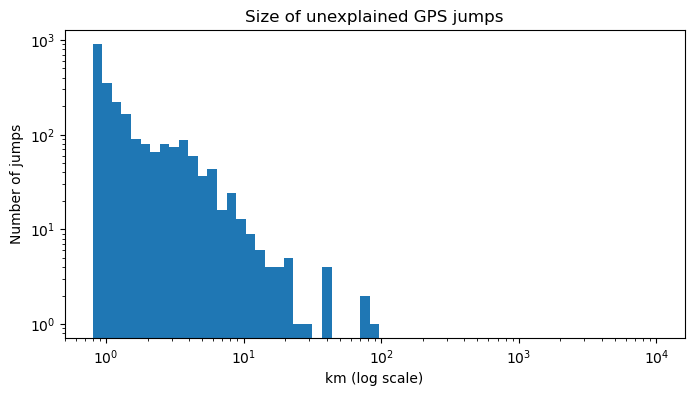

In [29]:
report_unexplained_jumps(pts)
plot_jump_sizes(pts)

## 13. Stationary trips
Trips with at least 2 points but less than 50 m in total distance

Sections 12 and 13 use a random sample of 100,000 trips, since splitting all polylines into points (about 83 million rows) needs too much memory. The sample is large enough for precise shares, so the numbers are estimates for the whole dataset.

In [30]:
trips["STATIONARY"] = (trips["N_POINTS"] >= 2) & (trips["DISTANCE_KM"] < 0.05)

n = trips["STATIONARY"].sum()
print(f"Stationary trips: {n:,} ({n/len(trips):.2%}) -> about {n/len(trips)*len(df):,.0f} in the whole dataset\n")
print("Number of points in stationary trips:")
print(trips.loc[trips["STATIONARY"], "N_POINTS"].describe())

Stationary trips: 612 (0.61%) -> about 10,469 in the whole dataset

Number of points in stationary trips:
count    612.000000
mean       5.985294
std        6.790634
min        2.000000
25%        2.000000
50%        3.000000
75%        6.000000
max       59.000000
Name: N_POINTS, dtype: float64


# 14. Identify trips with GPS faults

In [ ]:
# compute avg speed for valid trips
valid = select_valid_trips(df).copy()
valid["DISTANCE_KM"] = valid["POLYLINE"].apply(trip_distance_km)
hours = valid["DURATION_MIN"] / 60
valid["AVG_SPEED"] = valid["DISTANCE_KM"] / hours.where(hours > 0)

# identify trips with average speed above SPEED_THRESHOLD
high_speed = valid[valid["AVG_SPEED"] > SPEED_THRESHOLD].copy()
print(f"Nr of trips with average speed above {SPEED_THRESHOLD}: {high_speed.shape[0]}")

# identify speedy trips with jump
high_speed_points = polylines_to_points(high_speed).copy()
high_speed_steps = calculate_steps(high_speed_points).copy()
before = classify_bad_points(high_speed_points, MAX_STEP_M)
summary_before = trip_summary(before)
report_bad_points(before, summary_before)

Nr of trips with average speed above 50: 126381


In [35]:
# plot the trips with the fastest jumps
top_ten_fastest_jump_index = high_speed_steps[high_speed_steps["JUMP"]].sort_values(by=["SPEED_KMH"], ascending=False).TRIP_ID.tolist()[0:10]
high_speed_steps.groupby("TRIP_ID")["SPEED_KMH"].max().sort_values(ascending=False)
top_ten_fastest_jump = valid[valid["TRIP_ID"].isin(top_ten_fastest_jump_index)].copy()
top_ten_fastest_jump["POLYLINE"] = top_ten_fastest_jump["POLYLINE"].apply(json.loads).copy()
plot_trip(top_ten_fastest_jump)

In [36]:
# remove the classified bad points, recompute steps, repeat
after = before
for round_nr in range(1, 10):
    bad = after["ERROR_TYPE"] != ""
    print(f"Round {round_nr}: removing {bad.sum():,} bad points")
    if not bad.any():
        break
    kept = after.loc[~bad, ["TRIP_ID", "LONGITUDE", "LATITUDE"]].copy()
    after = classify_bad_points(calculate_steps(kept), MAX_STEP_M)

Round 1: removing 3,545 bad points
Round 2: removing 10 bad points
Round 3: removing 0 bad points


In [37]:
# compare before and after, one row per trip
summary_after = trip_summary(after).reindex(summary_before.index, fill_value=0)
trip_hours = high_speed.set_index("TRIP_ID")["DURATION_MIN"] / 60
status = pd.DataFrame({
    "JUMPS_BEFORE": summary_before["N_JUMPS"],
    "JUMPS_AFTER": summary_after["N_JUMPS"],
    "POINTS_REMOVED": summary_before["N_POINTS"] - summary_after["N_POINTS"],
    "AVG_SPEED_BEFORE": summary_before["DISTANCE_KM"] / trip_hours,
    "AVG_SPEED_AFTER": summary_after["DISTANCE_KM"] / trip_hours,
})
status["OUTCOME"] = np.select(
    [status["JUMPS_BEFORE"] == 0, status["JUMPS_AFTER"] == 0],
    ["no jumps", "fixed"],
    default="still jumping",
)

print(status["OUTCOME"].value_counts(), "\n")
display(status.loc[status["OUTCOME"] != "no jumps", ["AVG_SPEED_BEFORE", "AVG_SPEED_AFTER"]].describe())
report_unexplained_jumps(after)

OUTCOME
no jumps         110474
still jumping     13009
fixed              2898
Name: count, dtype: int64 



,AVG_SPEED_BEFORE,AVG_SPEED_AFTER
count,15907.000000,15907.000000
mean,100.085421,74.185354
std,367.928458,245.416287
min,50.002009,0.000000
25%,58.342048,53.250049
50%,69.766114,63.344606
75%,91.918460,80.336041
max,28835.193605,28835.193605


count     18917.000000
mean       3492.792073
std       13379.924335
min         833.343509
25%         982.166033
50%        1315.793344
75%        2903.123320
90%        6059.913350
99%       37779.951538
max      586932.727785
Name: STEP_M, dtype: float64 

Jumps of  1 km or less: 26.8%
Jumps of  2 km or less: 67.0%
Jumps of  3 km or less: 75.8%
Jumps of  5 km or less: 86.4%
Jumps of 10 km or less: 96.1%
Jumps of 50 km or less: 99.3%


In [ ]:
# trips that still have at least one jump after cleaning
jumping_ids = after.loc[after["JUMP"], "TRIP_ID"].unique()

# keep only the other trips
after_ok = after[~after["TRIP_ID"].isin(jumping_ids)]
print(f"Removed {len(jumping_ids):,} of {len(high_speed_steps[high_speed_steps["JUMP"]].TRIP_ID.unique())} trips")

# rebuild the polylines
cleaned_polylines = (
    after_ok.assign(COORD=after_ok[["LONGITUDE", "LATITUDE"]].values.tolist())
    .groupby("TRIP_ID", sort=False)["COORD"].agg(list)
    .rename("POLYLINE")
)

# trip table with the cleaned polylines instead of the original ones
valid_after = (
    valid[valid["TRIP_ID"].isin(cleaned_polylines.index)]
    .drop(columns="POLYLINE")
    .join(cleaned_polylines, on="TRIP_ID")
)

# rank trips by their fastest remaining step, one entry per trip
max_speed = after_ok.groupby("TRIP_ID")["SPEED_KMH"].max().sort_values(ascending=False)
fastest_ids = max_speed.index[:10]
slowest_ids = max_speed.index[-10:]

plot_trip(valid_after[valid_after["TRIP_ID"].isin(fastest_ids)])

Removed 13,009 of 15907 trips


,TRIP_ID,LONGITUDE,LATITUDE,STEP_M,SPEED_KMH,JUMP,ERROR_TYPE,UNEXPLAINED_JUMP
2143692,1380435273620000545,-8.622522,41.147802,833.285977,199.988634,False,,False
5791585,1397934946620000250,-8.620578,41.152320,833.232093,199.975702,False,,False
6004381,1398917955620000554,-8.621082,41.147433,833.176529,199.962367,False,,False
2590735,1382244034620000624,-8.622468,41.147811,833.171740,199.961218,False,,False
2163694,1380507124620000395,-8.709588,41.324796,833.134590,199.952302,False,,False
...,...,...,...,...,...,...,...,...
7504078,1404143355620000314,-8.585730,41.148621,NaN,NaN,False,,False
7504158,1404020381620000510,-8.630127,41.155398,NaN,NaN,False,,False
7504203,1404171659620000597,-8.649594,41.154273,NaN,NaN,False,,False
7504279,1403935197620000205,-8.663490,41.177466,NaN,NaN,False,,False


## 14. Findings and decisions

| Finding | Decision |
|---|---|
| DAY_TYPE only has the value A, even though the period contains public holidays | The column is removed |
| 10 rows have MISSING_DATA = True | The rows are removed, and then the MISSING_DATA column is removed |
| 80 TRIP_IDs are duplicated (161 rows, including 3 identical rows). Same taxi and timestamp, but different POLYLINE/CALL_TYPE | In most pairs the first row has more points than the second, but since many pairs have the same number of points or more points in the second row, it is hard to say which row is correct. All 161 rows are removed. TRIP_ID is then unique and is used as primary key |
| 11 302 trips with CALL_TYPE B are missing ORIGIN_STAND | The trips are kept, and ORIGIN_STAND is stored as NULL |
| TRIP_ID is a 19-digit number | Stored as BIGINT |
| ORIGIN_CALL and ORIGIN_STAND are float because of NaN | Stored as INT that allows NULL |
| TIMESTAMP is Unix time (seconds since 01.01.1970, UTC) | Converted to DATETIME in local Porto time (Europe/Lisbon, takes daylight saving time into account) |
| 5 901 trips have 0 GPS points, 43 904 have fewer than 3 | Trips with fewer than two GPS points are removed, as they do not drive from one point to another |
| 2 257 trips last more than 2 hours (max about 16 h). 37 % of them have an average speed below 10 km/h, while a quarter have more than 35 km/h | Trips longer than 2 hours with an average speed below 10 km/h are treated as a forgotten taximeter and removed. Long trips with a higher average speed are real long-distance trips and are kept |
| About 2.2 % of the trips have at least one GPS jump above 200 km/h (estimated from a random sample of 100,000 trips)| Trips with only one jump are kept |
| About 0.6 % of the trips are stationary (at least 2 points, less than 50 m total distance) (estimated from a random sample of 100,000 trips)| Removed |
| 641 trips (0.04 %) start more than 30 km from Porto City Hall. 76 have only one point, 8 have a wrong first point, and 557 are almost exclusively C trips (no B trips) with a median start distance of 55 km, of which 69 % end closer to Porto | No separate radius rule. The single points are handled by the rule for few points, and wrong first points by the rule for GPS jumps. The rest are interpreted as real return trips and are kept |
| 448 taxis, on average about 3 800 trips per taxi; a few have very few trips | No action needed |
| The period is 01.07.2013–30.06.2014 as expected (shifted by one hour in local time); most traffic on Fridays and at 8–9 am | No action needed |